# INF-616 - Tarefa 1

Professor: Alexandre Ferreira -- melloferreira@ic.unicamp.br  
Monitor: Lucas David -- ra188972@students.ic.unicamp.br

Instituto de Computação - Unicamp  
2018

## Classificação binária (decisão)

In [1]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from __future__ import print_function

%matplotlib inline

Breast Cancer Wisconsin (Diagnostic) Database

Notes
-----
Data Set Characteristics:
    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry 
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 3 is Mean Radius, field
        13 is Radius SE, field 23 is Worst Radius.

        

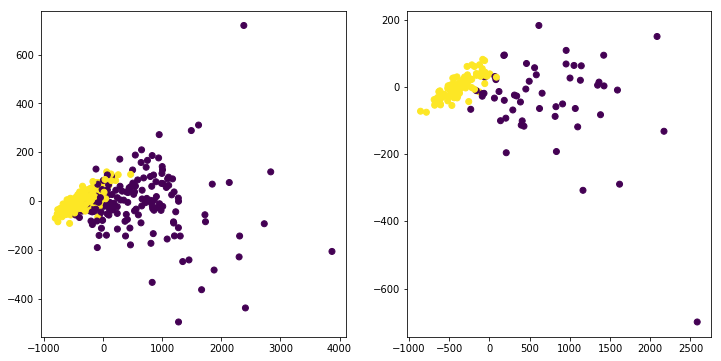

In [2]:
dataset = load_breast_cancer()
x_train, x_test, y_train, y_test = train_test_split(dataset.data, dataset.target,
                                                    test_size=0.25,
                                                    random_state=42)
print(dataset.DESCR)

embed = PCA(n_components=2).fit(x_train)
e_train = embed.transform(x_train)
e_test = embed.transform(x_test)

_ = plt.figure(figsize=(12, 6))
for ix, (phase, e, y) in enumerate((('train', e_train, y_train),
                                    ('test', e_test, y_test))):
    _ = plt.subplot(1, 2, ix + 1)
    _ = plt.scatter(e[:, 0], e[:, 1], c=y)

Gráfico exibindo as duas primeiras características do sub-conjunto de treino:


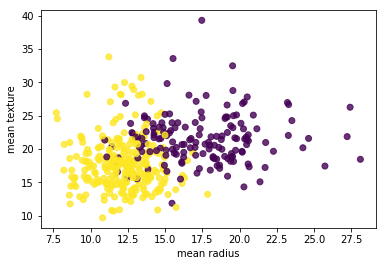

In [3]:
print('Gráfico exibindo as duas primeiras características do sub-conjunto de treino:')
_ = plt.scatter(x_train[:, 0], x_train[:, 1],
                c=y_train,
                alpha=0.8)
_ = plt.xlabel(dataset.feature_names[0])
_ = plt.ylabel(dataset.feature_names[1])

In [4]:
estimators = [SVC(random_state=13), LogisticRegression(random_state=24)]

for e in estimators:
    print('Treinando estimator', type(e).__name__)
    e.fit(x_train, y_train)

print('Todos os estimatores foram treinados!')

Treinando estimator SVC
Treinando estimator LogisticRegression
Todos os estimatores foram treinados!


### Qual dos dois estimadores apresenta menor taxa de erro sobre o conjunto WDBC teste?

In [5]:
for e in estimators:
    print('Teste do estimator', type(e).__name__)
    p_train = e.predict(x_train)
    
    print('exemplo de rótulos de treino verdadeiros:', y_train[:10], '...')
    print('exemplo de rótulos de treino preditos:', p_train[:10], '...')

    # Aluno, preencha adequadamente o código abaixo!
    # ...
    # Resposta:
    # TODO: apagar isso antes da entrega aos alunos
    acc_train = metrics.accuracy_score(y_train, p_train)

    p_test = e.predict(x_test)
    acc_test = metrics.accuracy_score(y_test, p_test)
    # Pare suas modificações aqui!

    print('Acurácia sobre o conjunto de treino:', acc_train)
    print('Acurácia sobre o conjunto de teste:', acc_test, end='\n\n')

Teste do estimator SVC
exemplo de rótulos de treino verdadeiros: [1 0 1 0 0 0 1 0 1 1] ...
exemplo de rótulos de treino preditos: [1 0 1 0 0 0 1 0 1 1] ...
Acurácia sobre o conjunto de treino: 1.0
Acurácia sobre o conjunto de teste: 0.6223776223776224

Teste do estimator LogisticRegression
exemplo de rótulos de treino verdadeiros: [1 0 1 0 0 0 1 0 1 1] ...
exemplo de rótulos de treino preditos: [1 0 1 0 0 0 1 0 1 1] ...
Acurácia sobre o conjunto de treino: 0.9577464788732394
Acurácia sobre o conjunto de teste: 0.958041958041958



- Quantas vezes cada um dos estimadores errou, no conjunto de teste?  
  *R: O SVC errou 54 vezes, enquanto o LogisticRegression errou somente 6 vezes.*

### Os estimadores conseguem distinguir ambas as classes de forma satisfatória?

Utilize uma ou mais funções vistas em aula para descobrir se os classificadores efetivamente conseguem distinguir amostras benignas de malignas.

In [6]:
for e in estimators:
    print('Estimador', type(e).__name__)
    p_test = e.predict(x_test)
    
    # Resposta:
    # TODO: apagar isso antes de entrega aos alunos
    print('Matriz de confusão:')
    print(metrics.confusion_matrix(y_test, p_test), end='\n\n')

Estimador SVC
Matriz de confusão:
[[ 0 54]
 [ 0 89]]

Estimador LogisticRegression
Matriz de confusão:
[[50  4]
 [ 2 87]]



- Algum dos estimatores super-especificou sobre o conjunto de treinamento?  
  *R: Sim! A máquina de vetor de suporte com kernel RBF.*
- As pontuações mudam quando consideramos a frequência das classes?  
  *R: Sim! SVC apresentou uma baixa acurácia de 32% e LogisticRegression obteve 96%.*

### Apresente um relatório das principais métricas para ambos estimadores

In [7]:
for e in estimators:
    print('Estimador', type(e).__name__)
    
    p_test = e.predict(x_test)

    # Resposta:
    # TODO: apagar isso antes de entrega aos alunos
    print(metrics.classification_report(y_test, p_test,
                                        target_names=dataset.target_names),
          end='\n\n')

Estimador SVC
             precision    recall  f1-score   support

  malignant       0.00      0.00      0.00        54
     benign       0.62      1.00      0.77        89

avg / total       0.39      0.62      0.48       143


Estimador LogisticRegression
             precision    recall  f1-score   support

  malignant       0.96      0.93      0.94        54
     benign       0.96      0.98      0.97        89

avg / total       0.96      0.96      0.96       143




/mnt/files/envs/tf/lib/python3.6/site-packages/sklearn/metrics/classification.py:1135: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)


Qual estimador possui melhor *f-1 score*?  
*R: LogisticRegression, com 96%*